# Importing Lib & Data

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, log_loss, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Importing Dataset
data = pd.read_csv(r"C:\Users\cereb\OneDrive\Documents\Rishabh\Projects\Hotel Reservation\Data\clean_data.csv")
pd.set_option('display.max_columns',None)
pd.set_option('display.width',None)
pd.set_option('display.max_colwidth',None)

data.head()

,Unnamed: 0,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay,total_guest,booking_id
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,86.693382,189.266735,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,1
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,86.693382,189.266735,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,2
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,86.693382,189.266735,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,3
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.000000,189.266735,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,4
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.000000,189.266735,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2.0,5


In [3]:
# Adjusting the Data for Readibility
data.set_index("booking_id", inplace=True)
data.drop("Unnamed: 0", axis=1, inplace=True)
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay,total_guest
booking_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,86.693382,189.266735,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0
2,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,86.693382,189.266735,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0
3,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,86.693382,189.266735,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0
4,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.000000,189.266735,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.000000,189.266735,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2.0


In [4]:
# Backing up the Original Data
data_orginal = data.copy()

# Exploratory Data Analysis

In [5]:
# Basic Data Information
print("-"*60)
print("Information on Data Columns")
print(data.info())
print("-"*60)

# Description on the Dataset
print(f"\n{'-'*60}")
print("Description on Data")
print(data.describe())
print("-"*60)

# Check Null VaLues in the DataSet
print(f"\n{'-'*60}")
print("Check Null Values")
print(data.isnull().sum())
print("-"*60)

------------------------------------------------------------
Information on Data Columns
<class 'pandas.core.frame.DataFrame'>
Index: 118728 entries, 1 to 118728
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118728 non-null  object 
 1   is_canceled                     118728 non-null  int64  
 2   lead_time                       118728 non-null  int64  
 3   arrival_date_year               118728 non-null  int64  
 4   arrival_date_month              118728 non-null  object 
 5   arrival_date_week_number        118728 non-null  int64  
 6   arrival_date_day_of_month       118728 non-null  int64  
 7   stays_in_weekend_nights         118728 non-null  int64  
 8   stays_in_week_nights            118728 non-null  int64  
 9   adults                          118728 non-null  int64  
 10  children                        118728 non-null  float64

In [6]:
# Data Size
print('-'*60)
print("Pre-Cleaned Data")
print(f"Total Rows is {data.shape[0]} and Total Columns are {data.shape[1]}")
print('-'*60)

------------------------------------------------------------
Pre-Cleaned Data
Total Rows is 118728 and Total Columns are 34
------------------------------------------------------------


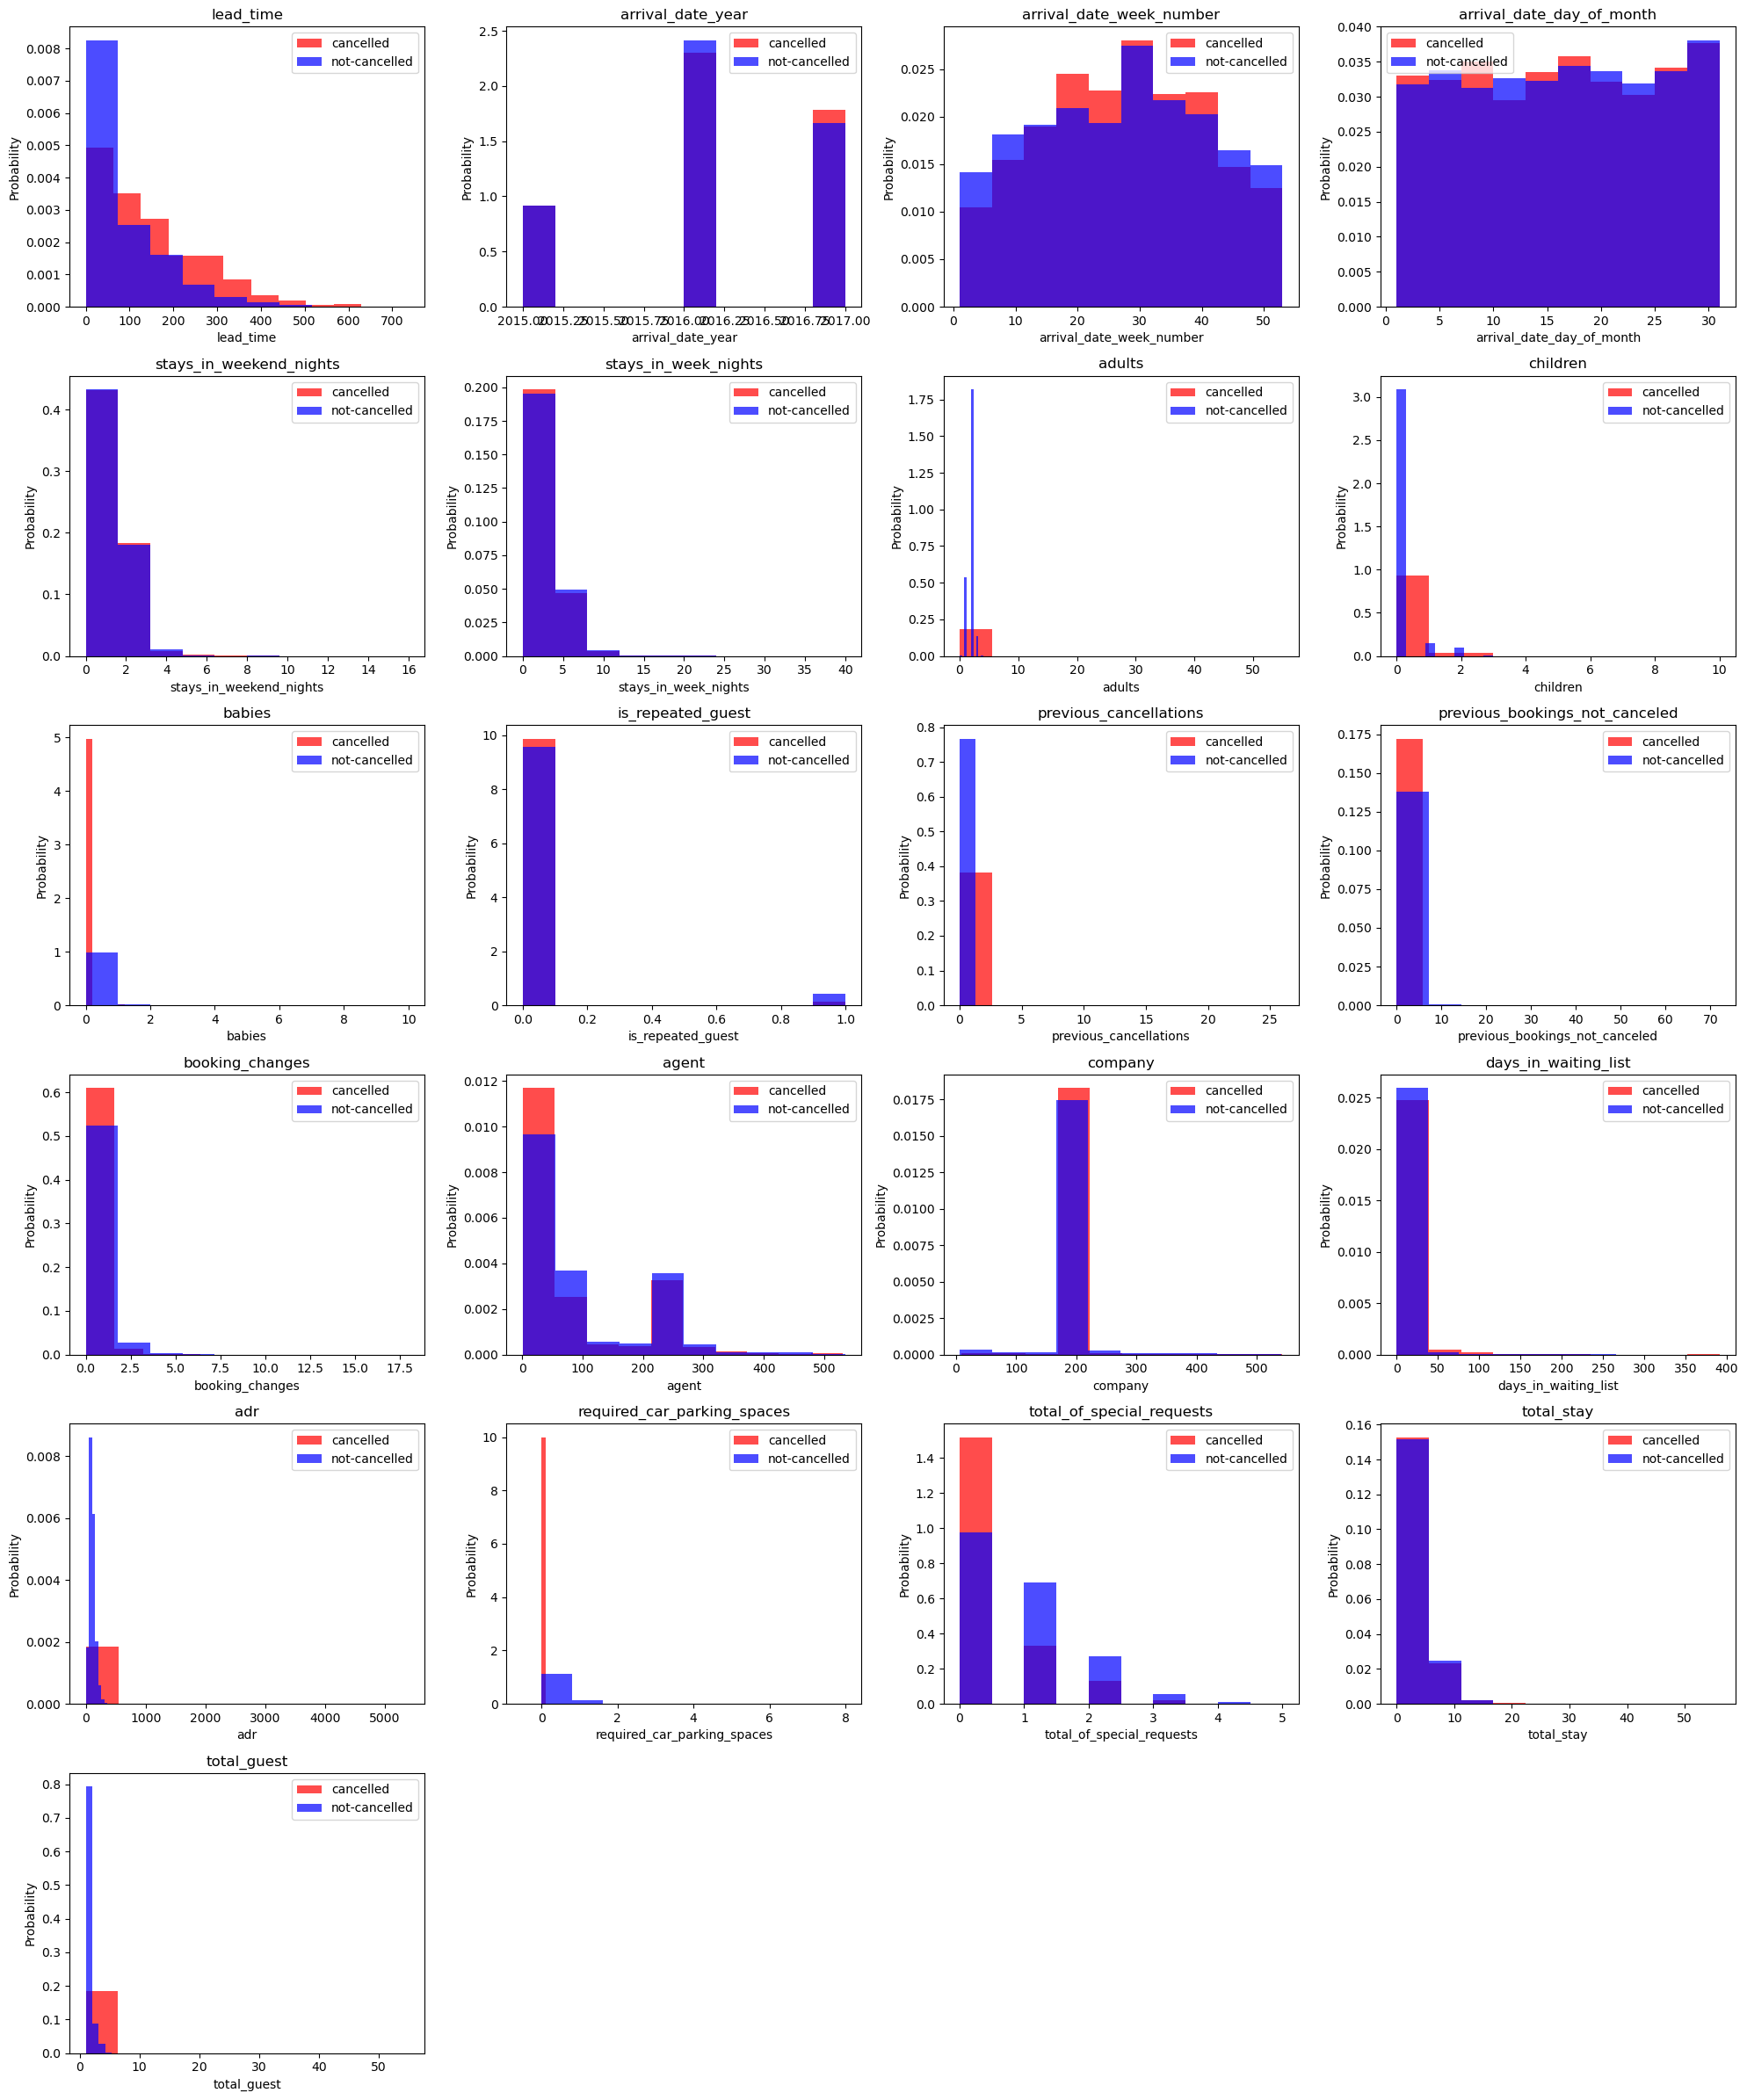

In [8]:
# Calculate the number of rows and columns for subplots
# Identify and remove outliers
numerical_features = data.select_dtypes(include=np.number).columns
features = numerical_features[1:]
initial_data_length = len(data)
n_features = len(features)
n_cols = 4 # You can adjust the number of columns as needed
n_rows = (n_features + n_cols - 1) // n_cols # Calculate the number of rows

# Create figure and subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4), squeeze=False)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot histograms for each feature
for i, label in enumerate(features):
    axes[i].hist(data[data["is_canceled"] == 1][label], color="red", label="cancelled", alpha=0.7, density=True)
    axes[i].hist(data[data["is_canceled"] == 0][label], color="blue", label="not-cancelled", alpha=0.7, density=True)
    axes[i].set_title(label)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel("Probability")
    axes[i].legend()

# Hide empty subplots if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Model Training 

In [9]:
# Training and Testing Dataset
train, valid, test = np.split(data.sample(frac=1),[int(0.6*len(data)), int(0.8*len(data))])

def scale_dataset(df, oversample = False):
    x = df.drop("is_canceled", axis=1)
    y = df["is_canceled"].values

    # Select only numerical columns for scaling
    numerical_cols = x.select_dtypes(include=np.number).columns
    x_numerical = x[numerical_cols]

    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_numerical)

    if oversample:
        ros = RandomOverSampler()
        x_scaled,y = ros.fit_resample(x_scaled,y)

    data = np.hstack((x_scaled,np.reshape(y, (-1,1))))

    return data, x_scaled, y

train_data, x_train, y_train = scale_dataset(train, oversample = True)
valid_data, x_valid, y_valid = scale_dataset(valid, oversample = False)
test_data, x_test, y_test = scale_dataset(test, oversample = False)

In [10]:
# Initial Model Training

models = {
    'KNN': KNeighborsClassifier(n_neighbors = 5),
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(probability=True),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators = 100, random_state=42),
    'Gradient Boost': GradientBoostingClassifier(n_estimators = 100, random_state=42),
    'ADA Boost': AdaBoostClassifier(n_estimators = 100, random_state=42),
}

result = []

for name, model in models.items():
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)

    # Identify if the data is Overfitting, underfitting or it is a balance fit
    
    y_train_pred = model.predict(x_train)
    train_accuracy_manual = accuracy_score(y_train, y_train_pred)

    y_pred_val = model.predict(x_valid)
    val_accuracy = accuracy_score(y_valid, y_pred_val)

    # Determine if overfitting, underfitting, or balanced
    if train_accuracy_manual > val_accuracy + 0.1:  # Threshold for overfitting
        fit_status = 'Overfitting'
        # Define parameter grid for GridSearchCV for overfitting models
        if name == 'KNN':
            param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}
        elif name == 'SVM':
            param_grid = {'C': [1, 0.1, 0.01, 0.11 ,10], 'gamma': [1, 0.1, 0.01, 0.11 ,10]}
        elif name == 'Decision Tree':
            param_grid = {'max_depth': [None, 10, 20, 30, 40], 'min_samples_split': [2, 5, 10, 12, 15, 20]}
        elif name == 'Random Forest':
            param_grid = {'n_estimators': [50, 100, 150, 200, 250, 300], 'max_depth': [None, 10, 20, 30, 40]}
        elif name == 'Gradient Boost':
            param_grid = {'n_estimators': [50, 100, 150, 200, 250, 300], 'learning_rate': [0.0001, 0.001, 0.01, 0.1, 0.11, 0.5, 0.7, 1]}
        elif name == 'ADA Boost':
            param_grid = {'n_estimators': [50, 100, 150, 200, 250, 300], 'learning_rate': [0.0001, 0.001, 0.01, 0.1, 0.11, 0.5, 0.7, 1]}
        else:
            param_grid = {} # No specific grid for other models

        if param_grid:
            grid_search = GridSearchCV(model, param_grid, cv=StratifiedKFold(n_splits=5))
            grid_search.fit(x_train, y_train)
            best_params = grid_search.best_params_
            best_score = grid_search.best_score_
        else:
            best_params = "N/A"
            best_score = "N/A"


    elif val_accuracy > train_accuracy_manual + 0.1: # Threshold for underfitting (less common)
        fit_status = 'Underfitting'
        best_params = "N/A"
        best_score = "N/A"
    else:
        fit_status = 'Balanced'
        best_params = "N/A"
        best_score = "N/A"


    # Store results
    result.append({
        'Model': name,
        'Accuracy': accuracy,
        'Training Accuracy': train_accuracy_manual,
        'Validation Accuracy': val_accuracy,
        'Fit Status': fit_status,
        'Best Parameters (GridSearchCV)': best_params,
        'Best Cross-Validation Score': best_score
    })


# Create DataFrame and display results
result_df = pd.DataFrame(result)
print("Initial Model Comparision Report (Training Data)")
result_df

Initial Model Comparision Report (Training Data)


,Model,Accuracy,Training Accuracy,Validation Accuracy,Fit Status,Best Parameters (GridSearchCV),Best Cross-Validation Score
0,KNN,0.770403,0.869852,0.774909,Balanced,N/A,N/A
1,Logistic Regression,0.712373,0.722765,0.717552,Balanced,N/A,N/A
2,Naive Bayes,0.626632,0.570748,0.463236,Overfitting,N/A,N/A
3,SVM,0.766276,0.770605,0.772130,Balanced,N/A,N/A
4,Decision Tree,0.784848,0.990978,0.787333,Overfitting,"{'max_depth': None, 'min_samples_split': 2}",0.875285
5,Random Forest,0.852228,0.990978,0.854712,Overfitting,"{'max_depth': 40, 'n_estimators': 300}",0.911498
6,Gradient Boost,0.770488,0.776777,0.772298,Balanced,N/A,N/A
7,ADA Boost,0.728796,0.739994,0.733471,Balanced,N/A,N/A


In [11]:
# Final Balanced models
models = {
    'KNN': KNeighborsClassifier(n_neighbors = 5),
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(probability=True),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators = 100, random_state=42),
    'Gradient Boost': GradientBoostingClassifier(n_estimators = 100, random_state=42),
    'ADA Boost': AdaBoostClassifier(n_estimators = 100, random_state=42)
}

results = []
k_folds = 3
for name, model in models.items():
    # Train model
    model.fit(x_train, y_train)
    
    # Make predictions
    y_pred = model.predict(x_test)
    y_pred_proba = model.predict_proba(x_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    loss = log_loss(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # K-Fold Cross Validation on training data
    cv_scores = cross_val_score(model, x_train, y_train, cv=k_folds)
    test_accuracy = accuracy_score(y_test, y_pred)

     # Determine if overfitting, underfitting, or balanced
    if train_accuracy_manual > val_accuracy + 0.1:
        fit_status = 'Overfitting'
        # K-Fold Cross Validation on training data
        cv_scores = cross_val_score(model, x_train, y_train, cv=k_folds)
        test_accuracy = accuracy_score(y_test, y_pred)
    elif val_accuracy > train_accuracy_manual + 0.1:
        fit_status = 'Underfitting'
    else:
        fit_status = 'Balanced'
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy*100,
        'Loss': loss,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        "Mean Accuracy": cv_scores.mean()*100,
        "Test Model Accuracy": test_accuracy*100,
        "Fit Status": fit_status
        
    })


# Create DataFrame and display results
results_df = pd.DataFrame(results)
report = results_df.set_index('Model')
report = report.sort_values(by='Mean Accuracy', ascending = False)
print(f"Final Model Comparision Report\n")
report

Final Model Comparision Report



,Accuracy,Loss,Precision,Recall,F1-score,Mean Accuracy,Test Model Accuracy,Fit Status
Model,,,,,,,,
Random Forest,85.222774,0.353075,0.851268,0.852228,0.850583,90.345950,85.222774,Balanced
Decision Tree,78.413206,7.489388,0.783959,0.784132,0.784044,86.676615,78.413206,Balanced
KNN,77.040344,2.177399,0.778125,0.770403,0.772655,79.199294,77.040344,Balanced
Gradient Boost,77.048766,0.476545,0.776042,0.770488,0.772313,77.524491,77.048766,Balanced
SVM,76.627643,0.495826,0.767356,0.766276,0.766765,76.177279,76.627643,Balanced
ADA Boost,72.879643,0.613696,0.745591,0.728796,0.732618,73.580125,72.879643,Balanced
Logistic Regression,71.237261,0.554370,0.728604,0.712373,0.716347,72.219496,71.237261,Balanced
Naive Bayes,62.663185,13.457552,0.687419,0.626632,0.484377,57.027861,62.663185,Balanced
